In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/drive/MyDrive/017'

batch_size = 8
image_size = (224, 224)

datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'  # Use the training split
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'  # Use the validation split
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
import os
import shutil
import random
import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from ast import main
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout,Dense, Flatten,BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adadelta,Adam,SGD,RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential

In [ ]:
import keras
import numpy as np


base_model = keras.applications.VGG19(weights='imagenet',
 include_top=False,
 input_shape=(224, 224, 3)
)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Increase dropout rate
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x) # Increase neurons
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
for layer in base_model.layers:
    layer.trainable = False
# Add the final output layer
output = Dense(2, activation='softmax')(x)
# Create the final model
model = Model(inputs=base_model.input, outputs=output)



optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adam"
)

model.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=['accuracy'])

80134624/80134624 [==============================] - 1s 0us/step


In [ ]:
from tensorflow.keras import models

In [ ]:
# Load the pre-trained VGG16 model
base_model = VGG19(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

# Create a new model on top of VGG16
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))  # Binary classification, so using 'sigmoid' activation

# Optionally, freeze the layers of the pre-trained VGG16 model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model using the generators
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1
)

Epoch 1/30
50/50 [==============================] - 416s 8s/step - loss: 2.6353 - accuracy: 0.6400 - val_loss: 0.3249 - val_accuracy: 0.8600
Epoch 2/30
50/50 [==============================] - 407s 8s/step - loss: 0.5442 - accuracy: 0.8075 - val_loss: 0.2437 - val_accuracy: 0.9300
Epoch 3/30
50/50 [==============================] - 406s 8s/step - loss: 0.2668 - accuracy: 0.8825 - val_loss: 0.0865 - val_accuracy: 0.9600
Epoch 4/30
50/50 [==============================] - 399s 8s/step - loss: 0.2372 - accuracy: 0.8975 - val_loss: 0.0543 - val_accuracy: 0.9900
Epoch 5/30
50/50 [==============================] - 402s 8s/step - loss: 0.2496 - accuracy: 0.9025 - val_loss: 0.0993 - val_accuracy: 0.9500
Epoch 6/30
50/50 [==============================] - 401s 8s/step - loss: 0.2165 - accuracy: 0.8950 - val_loss: 0.1028 - val_accuracy: 0.9600
Epoch 7/30
50/50 [==============================] - 397s 8s/step - loss: 0.1458 - accuracy: 0.9400 - val_loss: 0.2179 - val_accuracy: 0.9200
Epoch 8/30
50

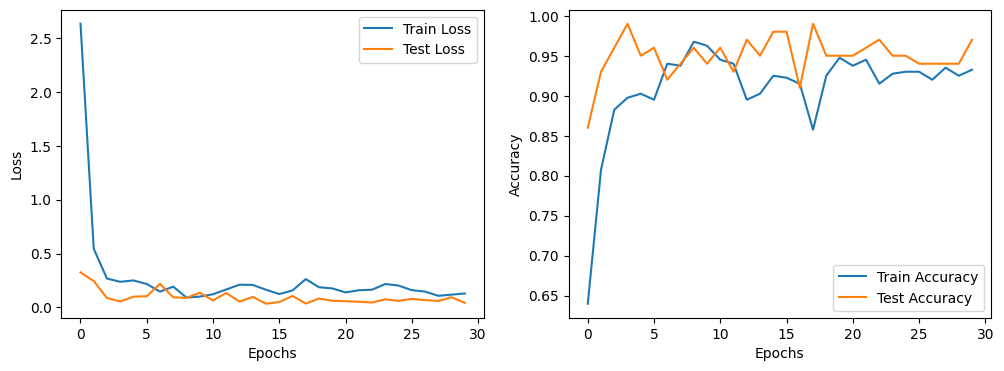

In [ ]:
# Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
predictions = model.predict(validation_generator)
y_true = validation_generator.classes
y_pred = predictions.argmax(axis=-1)
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy *100:.2f}%")

13/13 [==============================] - 84s 6s/step
Accuracy: 50.00%


1/1 [==============================] - 3s 3s/step


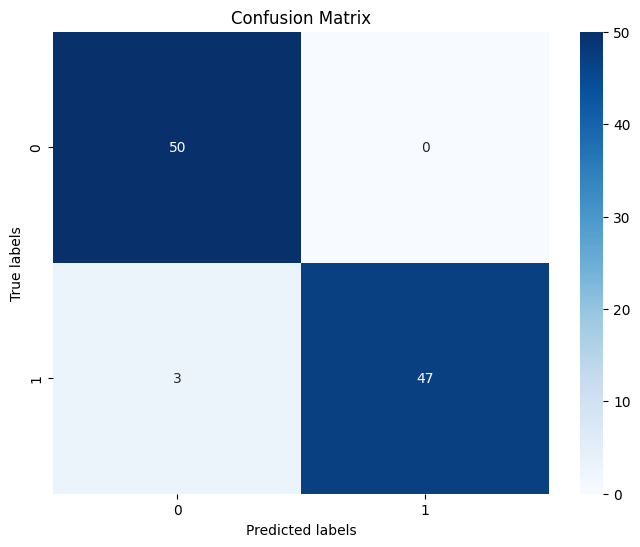


Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97        50
         1.0       1.00      0.94      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report  # Add this line
# Evaluate the model using confusion matrix and classification report
validation_steps = len(validation_generator)
y_true = []
y_pred = []
for i in range(validation_steps):
    images, labels = validation_generator[i]
    y_true.extend(labels)
    y_pred.extend(model.predict(images).flatten() > 0.5)

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# Assuming y_true and y_pred are defined
# Calculate the confusion matrix
confusion_matrix_data = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

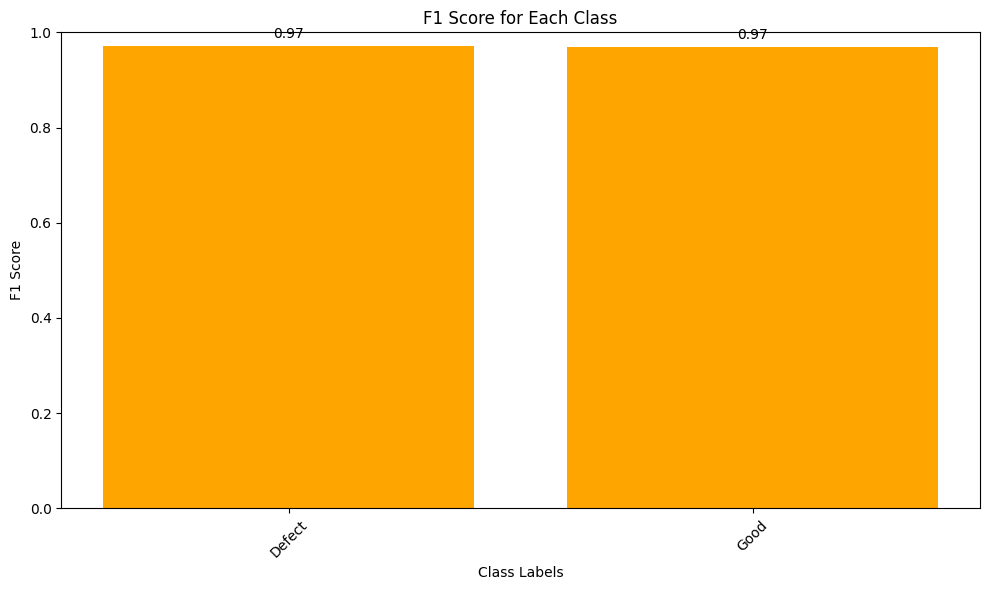

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Calculate F1 scores for each class
f1_scores = f1_score(y_true, y_pred, average=None)

# Get class labels
class_labels = list(validation_generator.class_indices.keys())

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(class_labels, f1_scores, color='Orange')
plt.xlabel('Class Labels')
plt.ylabel('F1 Score')
plt.title('F1 Score for Each Class')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limit to the range of F1 scores (0 to 1)

# Annotate each bar with its corresponding F1 score
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, round(score, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()
